In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\hamed\.cache\kagglehub\datasets\subhaditya\fer2013plus\versions\1


In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define data transformations
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Assuming grayscale images
    ]),
    "test": transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train"  # Adjust based on extracted folder structure
test_dir = path + "/fer2013plus/fer2013/test"    # Adjust based on extracted folder structure

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train loader and test loader created!")


# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)


# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Train loader and test loader created!
Image batch shape: torch.Size([32, 3, 48, 48])
Labels batch shape: torch.Size([32])
Labels: tensor([5, 4, 0, 4, 3, 6, 4, 4, 6, 0, 6, 7, 6, 6, 5, 4, 5, 3, 4, 4, 2, 5, 0, 6,
        5, 5, 5, 0, 5, 4, 5, 5])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


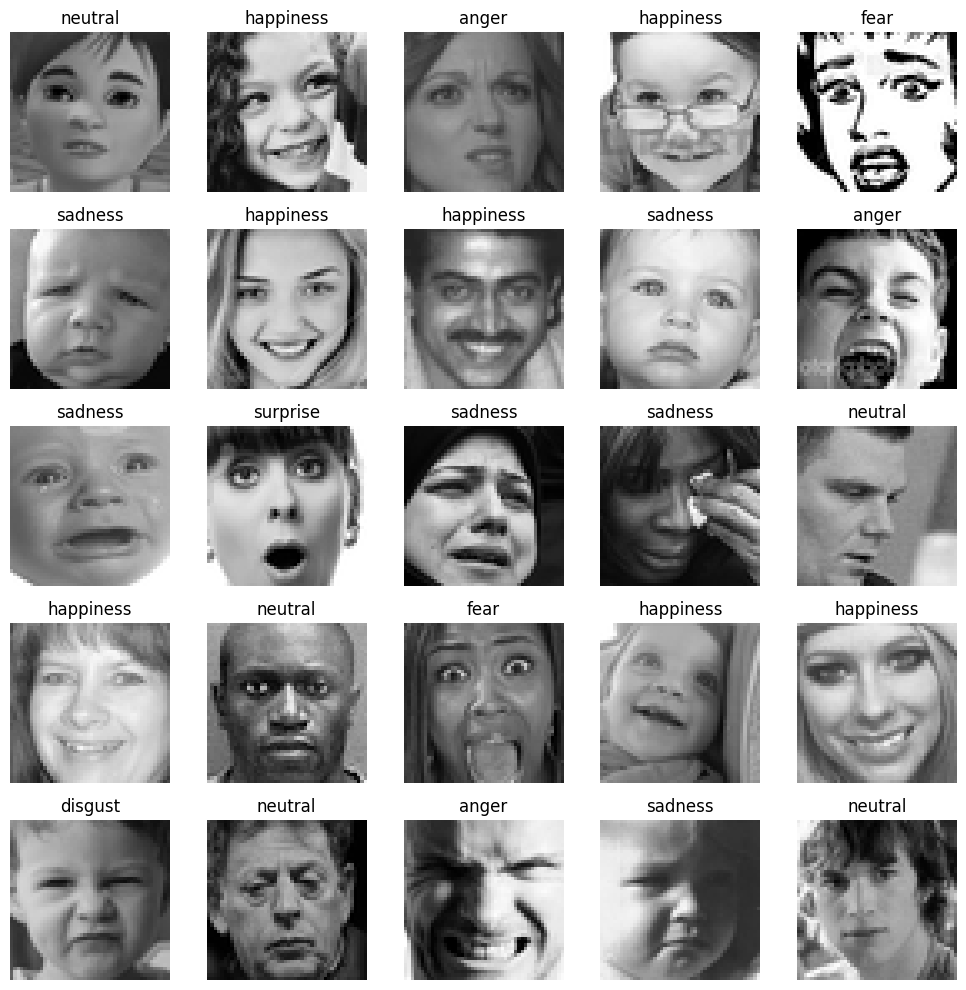

In [3]:
import matplotlib.pyplot as plt

# Function to plot a batch of images with labels
def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """
    # Convert the images to numpy for plotting
    images = images.permute(0, 2, 3, 1).numpy()  # Change from [C, H, W] to [H, W, C]

    # Denormalize the images (reverse normalization)
    images = images * 0.5 + 0.5  # Assuming normalization was (-0.5, 0.5)

    # Set up a grid for plotting
    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5)  # Square grid approximation
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:
            # Display the image
            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)
            # Set the title as the class label
            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:
            # Turn off axes for empty plots
            ax.axis("off")
    plt.tight_layout()
    plt.show()


# Plot a sample batch
plot_image_batch(images, labels, class_names)
